In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Checkerboard_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding
from torch.utils.data import DataLoader

In [11]:
n_rows = 4
batch_size = 10000

checkerboard_dataset = Checkerboard_Dataset(n_rows, dataset_size=100000)


loader = DataLoader(checkerboard_dataset, batch_size=batch_size, shuffle = True)
batch = next(iter(loader))
# first_sample = batch[0]
print("sample shape of checkerboard dataset", batch.shape)

sample shape of checkerboard dataset torch.Size([10000, 2])


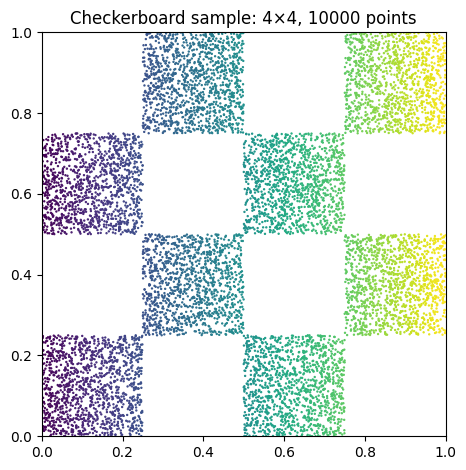

In [12]:
fig,ax = plt.subplots()
ax.scatter(batch[:,0],batch[:,1],s = 0.5, c= batch[:,0], cmap = "viridis")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title(f"Checkerboard sample: {n_rows}×{n_rows}, {batch_size} points")
plt.tight_layout()
plt.show()

torch.Size([10000, 2])
torch.Size([10000, 3])


Text(0.5, 0.92, 'Checkerboard on 2d torus')

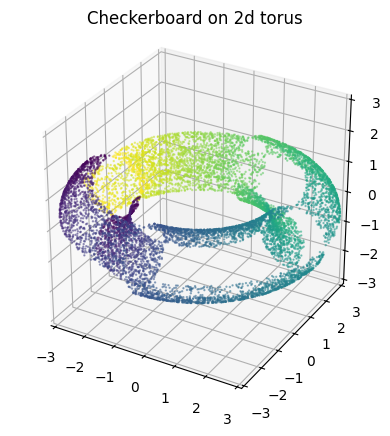

In [13]:
# Lie torus data like checkerboard
Torus_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(Torus_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))
print(batched_sample.shape)
theta1 = batched_sample[:,0]
theta2 = batched_sample[:,1]
# using 3d torus embedding to plot the checkerboard
torusEmbedding = torus_embedding(theta1,theta2)
print(torusEmbedding.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(torusEmbedding[:,0],torusEmbedding[:,1],torusEmbedding[:,2],c=theta1,cmap = "viridis", s = 0.5, alpha = 0.5)
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_zlim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on 2d torus")

Text(0.5, 1.0, 'Checkerboard on -pi, pi coordinate')

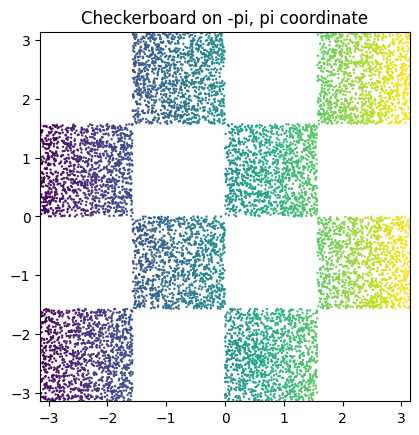

In [14]:
# plot checker board on the -pi, pi coordinate
fig,ax = plt.subplots()
ax.scatter(theta1,theta2,s = 0.5, c=theta1, cmap = "viridis")
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on -pi, pi coordinate")

## Sample Forward of checkerboard dataset from TDM diffusion model.

torch.Size([10000, 2])
shape of each batch torch.Size([10000, 2])


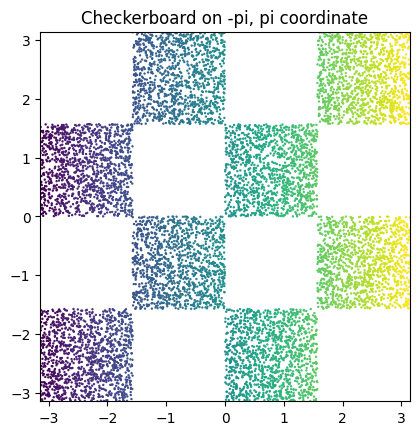

In [15]:
import src.diffusion as diffusion
import src.sde as sde

model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler", simplified_param=False)
dataset_size = 100000
batch_size = 10000
checkerboard_dataset = Checkerboard_Dataset(n_rows, dataset_size=dataset_size)
matrix_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(matrix_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))

fig,ax = plt.subplots()
ax.scatter(batched_sample[:,0],batched_sample[:,1],s = 0.5, c=batched_sample[:,0], cmap = "viridis")
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on -pi, pi coordinate")




print(batched_sample.shape)
theta1 = batched_sample[:,0]
theta2 = batched_sample[:,1]
print("shape of each batch",batched_sample.shape)
# Fixed times on the forward process
constant_t_forward = (0.01, 0.4, 0.7, 1.0, 15.0)
unconditional_samples = []
scores = []
# sample the forward process at fixed times
for i in range(len(constant_t_forward)):
    unconditional_sample_i, score_i = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = constant_t_forward[i])
    unconditional_samples.append(unconditional_sample_i)
    scores.append(score_i)
# shape: unconditional_samples: (constant_t_forward, batch_size, 2)
# shape: scores: (constant_t_forward, batch_size, 2)

shape of vts torch.Size([10000, 2])
shape of fts torch.Size([10000, 2])
shape of score torch.Size([10000, 2])
shape of fts of the first sample torch.Size([10000, 2])
shape of vts of the first sample torch.Size([10000, 2])
max of noised theta1 of the first sample tensor(3.1413)
min of noised theta1 of the first sample tensor(-3.1414)


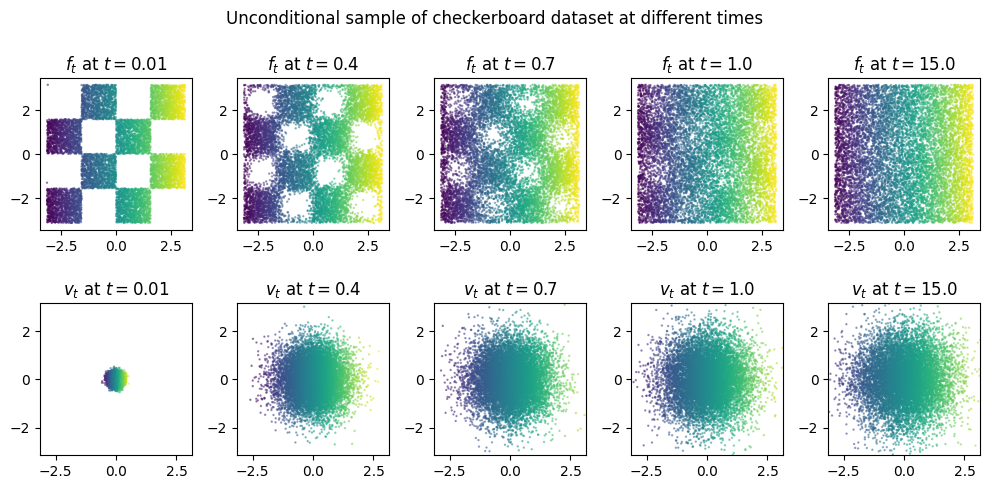

In [16]:
# extract the first sample of the unconditional samples
# post-process the unconditional samples to get the noised theta1 and theta2
fts_list = []
vts_list = []
theta1_noise_list = []
theta2_noise_list = []
scores_list = []
for ti in range(len(constant_t_forward)):
    vts_ti = unconditional_samples[ti][0]
    fts_ti = unconditional_samples[ti][1]
    scores_ti = scores[ti]
    theta1_noise_ti = fts_ti[:,0]
    theta2_noise_ti = fts_ti[:,1]
    fts_list.append(fts_ti)
    vts_list.append(vts_ti)
    theta1_noise_list.append(theta1_noise_ti)
    theta2_noise_list.append(theta2_noise_ti)
    scores_list.append(scores_ti)
    if ti == 0:
        print("shape of vts",vts_ti.shape)
        print("shape of fts",fts_ti.shape)
        print("shape of score",scores_ti.shape)
        print("shape of fts of the first sample",fts_ti.shape)
        print("shape of vts of the first sample",vts_ti.shape)
        # check the max and min of fts
        print("max of noised theta1 of the first sample",fts_ti[:,0].max())
        print("min of noised theta1 of the first sample",fts_ti[:,0].min())

# plot the unconditional sample for each constant t
fig,ax = plt.subplots(2,len(constant_t_forward),figsize=(10,5))
for i in range(len(constant_t_forward)):
    
    # plot the unconditional sample
    ax[0][i].scatter(theta1_noise_list[i],theta2_noise_list[i],c=theta1_noise_list[i],cmap = "viridis",s = 0.5,alpha = 0.5)
    # ax.set_xlim(-np.pi,np.pi)
    # ax.set_ylim(-np.pi,np.pi)
    ax[0][i].set_aspect("equal")
    ax[0][i].set_title("$f_t$ at $t=" + str(constant_t_forward[i]) + "$")
    ax[1][i].scatter(vts_list[i][:,0],vts_list[i][:,1],c=vts_list[i][:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
    ax[1][i].set_aspect("equal")
    ax[1][i].set_xlim(-np.pi,np.pi)
    ax[1][i].set_ylim(-np.pi,np.pi)
    ax[1][i].set_title("$v_t$ at $t=" + str(constant_t_forward[i]) + "$")
fig.suptitle("Unconditional sample of checkerboard dataset at different times") 
plt.tight_layout()
plt.show()

## Check the score of the forward process at exact time t

tensor(3.0638)
tensor(-3.0548)


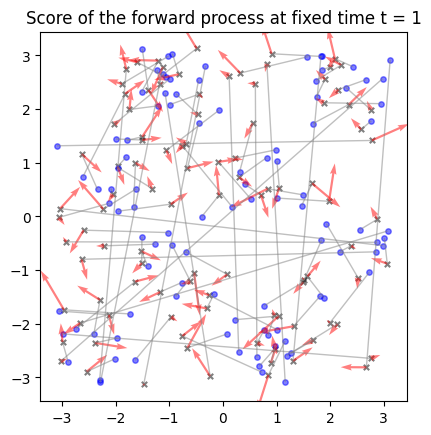

In [17]:
from matplotlib.collections import LineCollection
# Test on the smaller dataset
batch_size = 100
checkerboard_dataset = Checkerboard_Dataset(n_rows)
Lie_dataset = TorusLieWrapper(checkerboard_dataset)
Angle_dataset = AngleTorusWrapper(Lie_dataset)
data_loader_small = DataLoader(Angle_dataset, batch_size=batch_size, shuffle = True)

batched_sample = next(iter(data_loader_small))

fixed_t = 1
# sample the forward process at fixed time
model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler", simplified_param=False)
unconditional_sample, score_batched = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = fixed_t)

f0s_batched = batched_sample

vts_batched = unconditional_sample[0]
fts_batched = unconditional_sample[1]
theta1_noise_1st = fts_batched[:,0]
theta2_noise_1st = fts_batched[:,1]
print(max(theta1_noise_1st))
print(min(theta1_noise_1st))
# plot the score of the forward process at fixed time
f0_pts = f0s_batched.reshape(-1,2).numpy()
fts_pts = fts_batched.reshape(-1,2).numpy()

segments = np.stack([f0_pts,fts_pts],axis = 1)

fig,ax = plt.subplots()
ax.scatter(fts_batched[:,0],fts_batched[:,1],c="black",s = 15,alpha = 0.5, marker = "x")
ax.scatter(f0s_batched[:,0],f0s_batched[:,1],c="blue",s = 15,alpha = 0.5, marker = "o")
# connect points in fts_batched and f0s_batched
lc = LineCollection(segments, colors="gray", alpha=0.5,linewidths=1)
ax.add_collection(lc)
ax.quiver(theta1_noise_1st,theta2_noise_1st,score_batched[:,0],score_batched[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Score of the forward process at fixed time t = " + str(fixed_t))
plt.show()










In [18]:
# Load the trained model


from src.diffusion import TDMDiffusion
from src.scoreNN import TDM_SimpleScoreMLP
model = TDMDiffusion(dim = 2, integrator_type = "Euler", simplified_param=True)
x_lifting_dim = 64
time_embedding_half_dim = 32  # must be even
hidden_dim = [128, 128]
output_dim = 2
score_nn = TDM_SimpleScoreMLP(
    dim = 2, 
    x_lifting_dim = x_lifting_dim, 
    time_embedding_half_dim = time_embedding_half_dim, 
    hidden_dim = hidden_dim, 
    output_dim = output_dim,
    with_sincos_position=True,
    only_sincos_position=True
)
state_dict = torch.load("simple_score_mlp_checkerboard.pt", map_location="cpu")
score_nn.load_state_dict(state_dict)

# Plot the learned score and real score given one point and time

# sample one point and time in [-pi, pi] x [-pi, pi]
test_point = torch.rand(size=(1,2)) * 2 * np.pi - np.pi
test_time = torch.rand(size=(1,1)) * 2
test_v0 = torch.zeros(size=(1,2))

print(test_point)
print(test_time)

# get the real score
latents, real_score = model.sample_forward(f0 = test_point, total_time = 2.0, t_dist_kw = "constant", constant_t = test_time)
vt = latents[0]
ft = latents[1]

print("test velocity and position:", vt,ft)


# get the predicted score
pred_score = score_nn(ft, vt, test_time)

real_score = (1- torch.exp(-test_time))/(1 + torch.exp(-test_time)) * real_score - vt/ (model.sde.sigma_t(test_time)**2)

pred_f_traj, pred_v_traj, t_list = model.sample_backward(fT_prior_kw="uniform", vT_prior_kw="stdGauss", data_shape=(3, 2), total_time=2.0, tdm_score_fn=score_nn, sample_trajectory=True)

print("predicted score campares to score ground truth:", pred_score, real_score)

print(pred_f_traj[-1])
print(test_point)
print(pred_v_traj[-3])
print(pred_v_traj[0].shape)



# plot the backward v trajectory
pred_v_traj_cpu = [v.detach().cpu() for v in pred_v_traj]
pred_vx_traj_cpu = [v[:,0].squeeze() for v in pred_v_traj_cpu]
pred_vy_traj_cpu = [v[:,1].squeeze() for v in pred_v_traj_cpu]

pred_vx_traj_cpu = pred_vx_traj_cpu[:-2]
pred_vy_traj_cpu = pred_vy_traj_cpu[:-2]
fig,ax = plt.subplots()
ax.plot(pred_vx_traj_cpu,pred_vy_traj_cpu, marker = "x")
ax.scatter(pred_vx_traj_cpu[0],pred_vy_traj_cpu[0], marker = "o",c = "red")
ax.scatter(pred_vx_traj_cpu[-1],pred_vy_traj_cpu[-1], marker = "o",c = "black")
ax.scatter(0,0, marker = "o",c = "green",s = 100)
ax.set_aspect("equal")
ax.set_title("Backward v trajectory")
plt.show()


# recoverd f0, real f0 and predicted score at ft, real score at ft




RuntimeError: Error(s) in loading state_dict for TDM_SimpleScoreMLP:
	size mismatch for score_net.hidden_layer_0.weight: copying a param with shape torch.Size([512, 512]) from checkpoint, the shape in current model is torch.Size([128, 128]).
	size mismatch for score_net.hidden_layer_0.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for score_net.output_layer.weight: copying a param with shape torch.Size([2, 512]) from checkpoint, the shape in current model is torch.Size([2, 128]).
	size mismatch for lifting_layer_hidden.weight: copying a param with shape torch.Size([512, 64]) from checkpoint, the shape in current model is torch.Size([128, 64]).
	size mismatch for lifting_layer_hidden.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([128]).

## Visualize Learned score field, both total score and velocities score

torch.Size([10000, 2])
tensor([[-0.0193,  0.0356],
        [-0.0198,  0.0349],
        [-0.0202,  0.0342],
        ...,
        [-0.0183,  0.0372],
        [-0.0188,  0.0364],
        [-0.0193,  0.0356]], grad_fn=<AddmmBackward0>)
tensor([0.0389, 0.0387, 0.0385,  ..., 0.0392, 0.0390, 0.0389],
       grad_fn=<StdBackward0>) tensor([-0.0061,  0.0486], grad_fn=<MeanBackward1>)
torch.Size([10000, 2])
tensor(-0.0271) tensor(0.0224)
tensor(0.0138) tensor(0.0910)


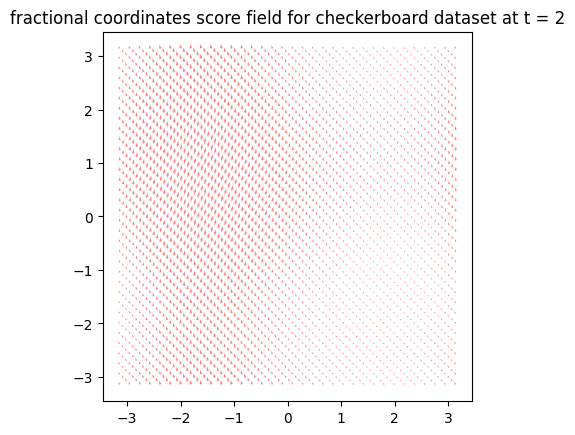

torch.Size([3334, 2])
torch.Size([1])


IndexError: tuple index out of range

In [ ]:



x_test = torch.linspace(-np.pi, np.pi, 100)
y_test = torch.linspace(-np.pi, np.pi, 100)
x_test, y_test = torch.meshgrid(x_test, y_test)
x_test = x_test.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
x_test = torch.cat([x_test, y_test], dim=-1)

x_test_batched = x_test[:,:]
print(x_test_batched.shape)
t_scalar = 2
v_scalar = 0
t_test = torch.full((10000, 1), t_scalar)   # (1, 10000, 1)
v_test = torch.ones_like(x_test_batched) * v_scalar

score = score_nn(x_test_batched, v_test, t_test)
print(score)
print(score.std(dim=1),score.mean(dim=0))
score = score.detach().cpu()
print(score.shape)
print(min(score[:,0]),max(score[:,0]))
print(min(score[:,1]),max(score[:,1]))

# shows every 3 points
score = score[::3,:]
x_test_batched = x_test_batched[::3,:]

fig,ax = plt.subplots()
# ax.scatter(x_test[:,0],x_test[:,1],c=x_test[:,0],cmap = "viridis",s = 0.5,alpha = 0.5)
ax.quiver(x_test_batched[:,0],x_test_batched[:,1],score[:,0],score[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"fractional coordinates score field for checkerboard dataset at t = {t_scalar}")
plt.show()


vx_test = torch.linspace(-3,3,100)
vy_test = torch.linspace(-3,3,100)
vx_test,vy_test = torch.meshgrid(vx_test,vy_test)
vx_test = vx_test.reshape(-1,1)
vy_test = vy_test.reshape(-1,1)
v_test = torch.cat([vx_test,vy_test],dim=-1)
v_test = v_test[:,:]
v_test = v_test[::3,:]
print(v_test.shape)
t_for_score = torch.Tensor([fixed_t])
print(t_for_score.shape)
t_for_score = t_for_score[:, None].expand(-1, v_test.shape[1])
score_v = (1- torch.exp(-t_for_score))/(1 + torch.exp(-t_for_score)) * score - v_test/ (model.sde.sigma_t(t_for_score)**2)

fig,ax = plt.subplots()
ax.quiver(v_test[:,0],v_test[:,1],score_v[:,0],score_v[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title(f"full score field for checkerboard dataset at t = {t_scalar}")
plt.show()


In [ ]:
ft_list, vt_list, t_list = model.sample_backward(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    data_shape=(10000, 2), 
    total_time=2.0,
    tdm_score_fn=score_nn,
    sample_trajectory=True
)






tensor([[ 1.6559, -2.9951],
        [-0.0905, -0.8358],
        [ 1.8302, -2.7182],
        ...,
        [ 2.0430, -2.6821],
        [-2.4573,  0.4068],
        [ 1.4663, -2.4312]], grad_fn=<Atan2Backward0>)
tensor([[ 1.6559, -2.9951],
        [-0.0905, -0.8358],
        [ 1.8302, -2.7182],
        ...,
        [ 2.0430, -2.6821],
        [-2.4573,  0.4068],
        [ 1.4663, -2.4312]], grad_fn=<Atan2Backward0>)
tensor([[-0.0626,  0.0667],
        [-0.0611, -0.1278],
        [ 0.1186, -0.0550],
        ...,
        [ 0.1477, -0.2942],
        [-0.2594, -0.2123],
        [-0.1043,  0.0787]], grad_fn=<AddBackward0>)
tensor(-3.1406, grad_fn=<UnbindBackward0>) tensor(3.1415, grad_fn=<UnbindBackward0>)
tensor(-3.1413, grad_fn=<UnbindBackward0>) tensor(3.1406, grad_fn=<UnbindBackward0>)


/tmp/ipykernel_2795734/175625721.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(fT_init[:,0],fT_init[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)


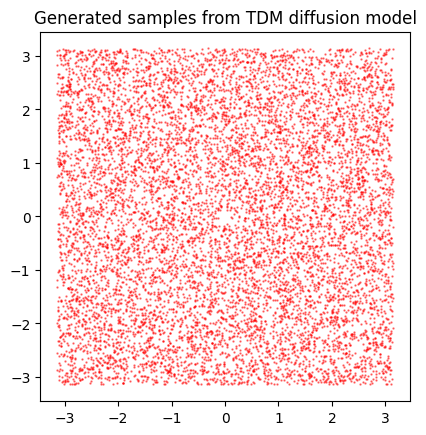

/tmp/ipykernel_2795734/175625721.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(fT_final[:,0],fT_final[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)


tensor([[ 1.6421, -3.0151],
        [-0.0820, -0.8364],
        [ 1.8844, -2.6691],
        ...,
        [ 2.1017, -2.5910],
        [-2.4632,  0.4321],
        [ 1.4942, -2.4356]])
tensor([[-0.1601,  0.2557],
        [ 0.0197, -0.5305],
        [-0.6098, -0.1510],
        ...,
        [ 0.6101,  0.1989],
        [ 0.1128,  0.4451],
        [-0.5461,  0.0484]])


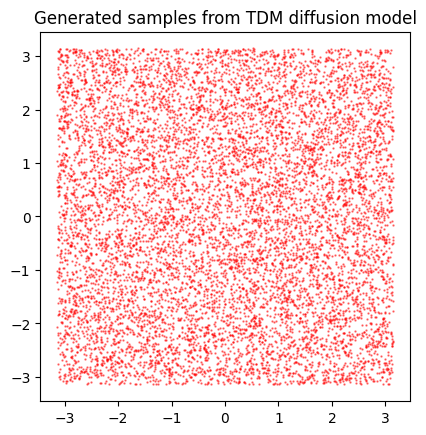

/tmp/ipykernel_2795734/175625721.py:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(vT_final[:,0],vT_final[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)


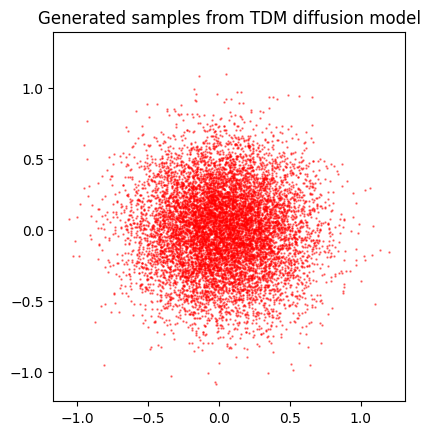

/tmp/ipykernel_2795734/175625721.py:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(vT_init[:,0],vT_init[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)


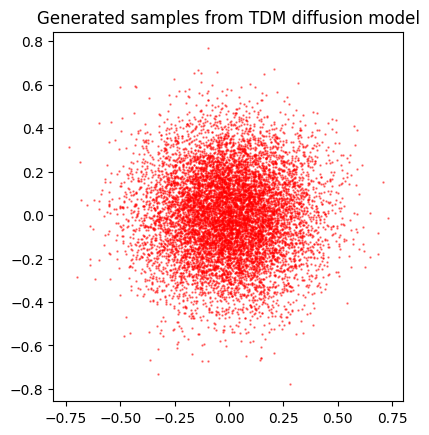

In [ ]:
fT_init = ft_list[0]
vT_init = vt_list[0]

print(fT_init)

print(fT_init)
print(vT_init)
print(min(fT_init[:,0]),max(fT_init[:,0]))
print(min(fT_init[:,1]),max(fT_init[:,1]))

fT_init = fT_init.detach().cpu()
vT_init = vT_init.detach().cpu()
fig,ax = plt.subplots()
ax.scatter(fT_init[:,0],fT_init[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Generated samples from TDM diffusion model")
plt.show()

fT_final = ft_list[-1].detach().cpu()
vT_final = vt_list[-1].detach().cpu()
print(fT_final)
print(vT_final)

fig,ax = plt.subplots()
ax.scatter(fT_final[:,0],fT_final[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Generated samples from TDM diffusion model")
plt.show()

fig,ax = plt.subplots()
ax.scatter(vT_final[:,0],vT_final[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Generated samples from TDM diffusion model")
plt.show()

fig,ax = plt.subplots()
ax.scatter(vT_init[:,0],vT_init[:,1],c="red",cmap = "viridis",s = 0.5,alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Generated samples from TDM diffusion model")
plt.show()



In [ ]:
import torch
score_nn.eval()
device = "cpu"
# sanity: what does the network output for a fixed f, v across t?
with torch.no_grad():
    B = 256
    f_test = torch.zeros(B,  2, device=device)             # f = 0
    v_test = torch.randn(B, 2, device=device) * 0.1       # small v
    for t_val in [0.05, 0.5, 1.0, 1.5, 1.95]:
        t_test = torch.full((B, 1), t_val, device=device)
        pred = score_nn(f_test, v_test, t_test)
        # what should the target be?
        sigma_v = model.sde.sigma_t(torch.tensor(t_val))
        expected_v_term = -v_test / (sigma_v**2)   # the dominant term at small v
        print(f"t={t_val:.2f}: pred mean={pred.mean().item():+.3f} std={pred.std().item():.3f} "
              f"| expected -v/σ² mean={expected_v_term.mean().item():+.3f} std={expected_v_term.std().item():.3f}")


t=0.05: pred mean=-0.021 std=0.013 | expected -v/σ² mean=-0.053 std=1.046
t=0.50: pred mean=-0.020 std=0.012 | expected -v/σ² mean=-0.008 std=0.157
t=1.00: pred mean=-0.019 std=0.010 | expected -v/σ² mean=-0.006 std=0.115
t=1.50: pred mean=-0.018 std=0.009 | expected -v/σ² mean=-0.005 std=0.105
t=1.95: pred mean=-0.016 std=0.007 | expected -v/σ² mean=-0.005 std=0.102


In [ ]:
score_nn.eval()
with torch.no_grad():
    B = 256
    # FIX f at different non-zero values, set v=0
    v_test = torch.zeros(B, 2)        # v = 0 to isolate WN term
    t_val = 0.5
    t_test = torch.full((B, 1), t_val)
    
    for f_val in [0.0, 1.0, 2.0, 3.0, -2.0]:
        f_test = torch.full((B, 2), f_val)
        pred = score_nn(f_test, v_test, t_test)
        print(f"f={f_val:+.1f}, v=0: pred mean={pred.mean(dim=0).squeeze().tolist()}, std={pred.std():.3f}")

f=+0.0, v=0: pred mean=[-0.03228382021188736, -0.007853352464735508], std=0.012
f=+1.0, v=0: pred mean=[-0.031029634177684784, -0.01166728138923645], std=0.010
f=+2.0, v=0: pred mean=[-0.03168525546789169, -0.010030245408415794], std=0.011
f=+3.0, v=0: pred mean=[-0.033344563096761703, -0.004693277645856142], std=0.014
f=-2.0, v=0: pred mean=[-0.03519180044531822, -0.000426215585321188], std=0.017


In [ ]:
score_nn.eval()
with torch.no_grad():
    B = 256
    f_test = torch.zeros(B, 2)              # f = 0
    t_test = torch.full((B, 1), 0.5)
    for v_val in [-1.0, -0.5, 0.0, 0.5, 1.0]:
        v_test = torch.full((B, 2), v_val)
        pred = score_nn(f_test, v_test, t_test)
        sig_v = model.sde.sigma_t(torch.tensor(0.5))
        expected = -v_val / (sig_v**2).item()
        print(f"v={v_val:+.2f}: pred[0]={pred[0,0].item():+.3f} pred[1]={pred[0,1].item():+.3f} | -v/σ²={expected:+.3f}")

v=-1.00: pred[0]=-0.033 pred[1]=-0.010 | -v/σ²=+1.582
v=-0.50: pred[0]=-0.033 pred[1]=-0.009 | -v/σ²=+0.791
v=+0.00: pred[0]=-0.032 pred[1]=-0.008 | -v/σ²=-0.000
v=+0.50: pred[0]=-0.032 pred[1]=-0.007 | -v/σ²=-0.791
v=+1.00: pred[0]=-0.032 pred[1]=-0.006 | -v/σ²=-1.582
